In [1]:
pip install porespy

  Using cached rich-13.7.1-py3-none-any.whl.metadata (18 kB)
     ---------------------------------------- 0.0/57.6 kB ? eta -:--:--
     --------------------- ------------------ 30.7/57.6 kB 1.3 MB/s eta 0:00:01
     -------------------------------------- 57.6/57.6 kB 598.9 kB/s eta 0:00:00
  Using cached wrapt-1.16.0-cp312-cp312-win_amd64.whl.metadata (6.8 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached markdown_it_py-3.0.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/164.7 kB ? eta -:--:--
   ---------------------- ----------------- 92.2/164.7 kB 2.6 MB/s eta 0:00:01
   ---------------------------------------- 164.7/164.7 kB 2.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ------- -------------------------------- 0.2/1.2 MB 7.0 MB/s eta 0:00:01
   ---------------- -----

In [13]:
pip install scikit-learn

   ---------------------------------------- 0.0/10.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.9 MB 640.0 kB/s eta 0:00:18
   ---------------------------------------- 0.1/10.9 MB 1.1 MB/s eta 0:00:11
    --------------------------------------- 0.2/10.9 MB 1.4 MB/s eta 0:00:08
   - -------------------------------------- 0.4/10.9 MB 2.1 MB/s eta 0:00:06
   -- ------------------------------------- 0.6/10.9 MB 2.6 MB/s eta 0:00:05
   --- ------------------------------------ 0.8/10.9 MB 2.9 MB/s eta 0:00:04
   ---- ----------------------------------- 1.2/10.9 MB 3.9 MB/s eta 0:00:03
   ---- ----------------------------------- 1.2/10.9 MB 3.9 MB/s eta 0:00:03
   ------ --------------------------------- 1.8/10.9 MB 4.4 MB/s eta 0:00:03
   -------- ------------------------------- 2.2/10.9 MB 4.9 MB/s eta 0:00:02
   --------- ------------------------------ 2.7/10.9 MB 5.2 MB/s eta 0:00:02
   -------------- ------------------------- 3.9/10.9 MB 6.9 MB/s eta 0:00:02
   -

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

In [2]:
import porespy as ps

# Generate a synthetic 2D porous material image
im = ps.generators.blobs(shape=[200, 200], porosity=0.28, blobiness=2)
im = im.astype('uint8')
# Threshold the image to separate void space and solid matrix
threshold_value = 0.5  # Adjust this threshold as needed
#binary_image = (im > threshold_value).astype(int)
binary_image = im > threshold_value
# Label connected components in the binary image
labeled_image, num_labels = ndi.label(binary_image)

[12:47:21] ERROR    PARDISO solver not installed, run `pip install pypardiso`. Otherwise,          ]8;id=757397;file://C:\Users\CometLake_04\.conda\envs\frank_env\Lib\site-packages\openpnm\utils\_workspace.py\_workspace.py]8;;\:]8;id=509720;file://C:\Users\CometLake_04\.conda\envs\frank_env\Lib\site-packages\openpnm\utils\_workspace.py#56\56]8;;\
                    simulations will be slow. Apple M chips not supported.                                         

C:\Users\CometLake_04\.conda\envs\frank_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
binary_image.shape, im.shape

((200, 200), (200, 200))

Random number: 101


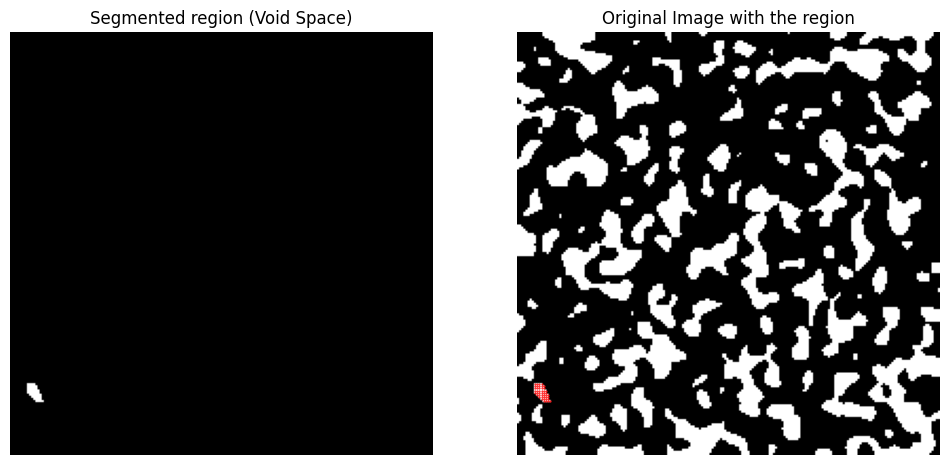

In [4]:
# Lista para salvar as regiões segmentadas (void space)
regioes_segmentadas = []

# Lista para salvar as coordenadas de cada região
coordenadas_poros = []

# Iterar sobre os diferentes rótulos de regiões na imagem rotulada
for label in range(1, num_labels + 1):
    # Encontrar os índices dos pixels da região na imagem rotulada
    indices_regiao = np.where(labeled_image == label)

    # Salvar as coordenadas x e y dos pixels da região na imagem original
    coords_x, coords_y = indices_regiao[1], indices_regiao[0]
    coordenadas_poros.append((coords_x, coords_y))

    # Extrair a região segmentada (void space) da imagem original
    regiao_segmentada = np.zeros_like(im)
    regiao_segmentada[coords_y, coords_x] = 1  # Atribuir 1 aos pixels da região
    regioes_segmentadas.append(regiao_segmentada)

import random
random_number = random.randint(0, len(regioes_segmentadas))  # Generates a random integer between 1 and 100 (inclusive)
print("Random number:", random_number)

# Exemplo de acesso a uma região segmentada e suas coordenadas
indice_da_regiao = random_number  # Índice da região desejada
regiao_segmentada_desejada = regioes_segmentadas[indice_da_regiao]
coordenadas_da_regiao_desejada = coordenadas_poros[indice_da_regiao]



# Visualizar a região segmentada e as coordenadas
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(regiao_segmentada_desejada, cmap='gray')
plt.title('Segmented region (Void Space)')
plt.axis('off')

plt.subplot(122)
plt.imshow(binary_image, cmap='gray')
plt.plot(coordenadas_da_regiao_desejada[0], coordenadas_da_regiao_desejada[1], 'r.', markersize=1)
plt.title('Original Image with the region')
plt.axis('off')

plt.show()

## Apply the k means 

In [100]:
# The number of pixels to consider a pore
pore_number = 30

In [203]:
distancia_maxima= pore_number * 0.25
distancia_maxima

7.5

In [204]:
# import numpy as np
# from sklearn.cluster import KMeans
# from skimage.measure import label, regionprops

# def apply_kmeans_to_region(region_segmentada, pore_number):
#     # Obter os pixels que são representados por 1 na região segmentada
#     pixels_0 = np.argwhere(region_segmentada == 1)

#     # Determinar o número de vezes que len(pixels_0) excede pore_number
#     excessos = len(pixels_0) // pore_number

#     # Ajustar o número de clusters com base nos excessos
#     num_clusters = max(1, excessos)

#     # Aplicar K-means aos pixels 0 para segmentá-los em clusters
#     kmeans = KMeans(n_clusters=num_clusters, random_state=42)
#     kmeans.fit(pixels_0)

#     # Obter os rótulos dos clusters atribuídos aos pixels 0
#     labels = kmeans.labels_

#     # Criar uma matriz com os rótulos dos clusters nas posições dos pixels 0
#     clustered_region = np.zeros_like(region_segmentada)
#     for label, pixel in zip(labels, pixels_0):
#         clustered_region[pixel[0], pixel[1]] = label + 1  # Adicionar 1 para evitar label 0

#     # Calcular os centros dos clusters
#     cluster_centers = kmeans.cluster_centers_

#     # Retornar a região clusterizada, o número de clusters e as coordenadas dos centros dos clusters
#     return clustered_region, num_clusters, cluster_centers

import numpy as np
from sklearn.cluster import KMeans
from skimage.measure import find_contours

def apply_kmeans_to_region(region_segmentada, pore_number):
    # Obter os pixels que são representados por 1 na região segmentada
    pixels_0 = np.argwhere(region_segmentada == 1)

    # Determinar o número de vezes que len(pixels_0) excede pore_number
    excessos = len(pixels_0) // pore_number

    # Ajustar o número de clusters com base nos excessos
    num_clusters = max(1, excessos)

    # Aplicar K-means aos pixels 0 para segmentá-los em clusters
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(pixels_0)

    # Obter os rótulos dos clusters atribuídos aos pixels 0
    labels = kmeans.labels_

    # Criar uma matriz com os rótulos dos clusters nas posições dos pixels 0
    clustered_region = np.zeros_like(region_segmentada)
    for label, pixel in zip(labels, pixels_0):
        clustered_region[pixel[0], pixel[1]] = label + 1  # Adicionar 1 para evitar label 0

    # Calcular os centros dos clusters
    cluster_centers = kmeans.cluster_centers_

    # Encontrar os contornos de cada cluster
    contornos_por_cluster = []
    for i in range(num_clusters):
        mask = clustered_region == (i + 1)  # Criar uma máscara para o cluster atual
        contornos = find_contours(mask, 0.5)  # Encontrar os contornos do cluster atual
        contornos_por_cluster.append(contornos)

    # Retornar a região clusterizada, o número de clusters, as coordenadas dos centros dos clusters e os contornos de cada cluster
    return clustered_region, num_clusters, cluster_centers, contornos_por_cluster



import numpy as np
from skimage.measure import label, regionprops

def calculate_aspect_ratios(clustered_region):
    # Rotular a imagem para obter clusters individuais
    labeled_image = label(clustered_region)
    regions = regionprops(labeled_image)

    aspect_ratios = []
    for region in regions:
        major_axis_length = region.major_axis_length
        minor_axis_length = region.minor_axis_length

        #print(f"Major axis length: {major_axis_length}, Minor axis length: {minor_axis_length}")  # Informações para depuração

        if major_axis_length > 0:  # Evitar divisão por zero
            aspect_ratio = minor_axis_length / major_axis_length
        else:
            aspect_ratio = 0
        aspect_ratios.append(aspect_ratio)

    return aspect_ratios


def calculate_areas(clustered_region):
    # Rotular a imagem para obter clusters individuais
    labeled_image = label(clustered_region)
    regions = regionprops(labeled_image)

    #aspect_ratios = []
    areas = []
    for region in regions:
        ##major_axis_length = region.major_axis_length
        ##minor_axis_length = region.minor_axis_length
        area = region.area

        # Calcular a razão de aspecto
        ##if major_axis_length > 0:  # Evitar divisão por zero
        ##    aspect_ratio = minor_axis_length / major_axis_length
        ##else:
        ##    aspect_ratio = 0
        
        ##aspect_ratios.append(aspect_ratio)
        areas.append(area)

    return areas

# Exemplo de uso
# region_segmentada deve ser a sua matriz de região segmentada
# clustered_region, _, _ = apply_kmeans_to_region(region_segmentada, pore_number)
# aspect_ratios = calculate_aspect_ratios(clustered_region)
# print(aspect_ratios)





# Lista para armazenar as coordenadas dos centros de cada região clusterizada
coordenadas_centros_kmeans = []
resultados_kmeans = []
number_of_pores_kmeans = []
ratio_of_aspect_cluster_kmeans = []
areas_cluster_kmeans = []
contour_per_cluster = []

# Plotar as regiões segmentadas após a aplicação do K-means
for i, region_segmentada in enumerate(regioes_segmentadas, start=1):
    # Aplicar o K-means à região segmentada atual
    clustered_region_kmeans, n_por_kmeans, centros_kmeans, contour_k_means = apply_kmeans_to_region(region_segmentada, pore_number)

    # Armazenar as coordenadas dos centros dos clusters na lista
    coordenadas_centros_kmeans.append(centros_kmeans)
    resultados_kmeans.append(clustered_region_kmeans)
    number_of_pores_kmeans.append(n_por_kmeans)
    # Calcular as razões de aspecto dos clusters
    aspect_ratios_kmeans = calculate_aspect_ratios(clustered_region_kmeans)
    areas_kmeans = calculate_areas(clustered_region_kmeans)
    ratio_of_aspect_cluster_kmeans.append(aspect_ratios_kmeans)
    areas_cluster_kmeans.append(areas_kmeans)
    contour_per_cluster.append(contour_k_means)

In [205]:
len(resultados_kmeans), len(contour_per_cluster)

(118, 118)

In [206]:
resultados_kmeans[1]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [207]:
contour_per_cluster[1],resultados_kmeans[1]

([[array([[ 0. , 72.5],
          [ 1. , 72.5],
          [ 2. , 72.5],
          [ 3. , 72.5],
          [ 4. , 72.5],
          [ 4.5, 72. ],
          [ 4. , 71.5],
          [ 3.5, 71. ],
          [ 3. , 70.5],
          [ 2. , 70.5],
          [ 1.5, 70. ],
          [ 1. , 69.5],
          [ 0. , 69.5]])]],
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8))

In [208]:
# import random
# import matplotlib.pyplot as plt

# # Comprimento da lista resultados_kmeans
# length = len(resultados_kmeans)

# # Gerar um número aleatório entre 0 e length-1
# random_index = random.randint(0, length - 1)

# # Gerar um número aleatório entre 0 e o comprimento da lista de resultados - 1
# random_number_kmean = random_index
# numero_de_elementos_na_regiao = np.count_nonzero(resultados_kmeans[random_number_kmean])
# print("Random number_kmean:", random_number_kmean, numero_de_elementos_na_região, 'number_of_pores', number_of_pores_kmeans[random_number])

# # Obter a região clusterizada aleatória e seus centros
# regiao_aleatoria = resultados_kmeans[random_number_kmean]
# centros = coordenadas_centros_kmeans[random_number_kmean]

# # Inicializar uma figura
# plt.figure(figsize=(10, 10))

# # Plotar a região clusterizada
# plt.subplot(121)
# plt.imshow(regiao_aleatoria)
# plt.title('Clusterized region')

# # Plotar os centros dos clusters
# for centro in centros:
#     plt.scatter(centro[1], centro[0], color='red', marker='o', s=5)

# # Inicialize uma variável para contar o número de ligações
# numero_de_ligacoes = 0

# # Lista para armazenar os vetores trajetórias
# vetores_trajetorias = []

# # Variável para armazenar a maior trajetória
# maior_trajetoria = (None, None, 0)  # (ponto inicial, ponto final, comprimento)

# # Identificar mudanças de valor de pixel entre as regiões clusterizadas
# for i in range(1, length):
#     regiao_anterior = resultados_kmeans[i - 1]
#     regiao_atual = resultados_kmeans[i]
#     if not np.array_equal(regiao_anterior, regiao_atual):
#         # Conectar os centros dos clusters das regiões
#         centros_anterior = coordenadas_centros_kmeans[i - 1]
#         centros_atual = coordenadas_centros_kmeans[i]
#         for centro_anterior in centros_anterior:
#             for centro_atual in centros_atual:
#                 plt.plot([centro_anterior[1], centro_atual[1]], [centro_anterior[0], centro_atual[0]], 'r-', linewidth=0.5)
#                 numero_de_ligacoes += 1

# # Exemplo de acesso a uma região segmentada e suas coordenadas
# indice_da_regiao = random_number_kmean  # Índice da região desejada
# regiao_segmentada_desejada = regioes_segmentadas[indice_da_regiao]
# coordenadas_da_regiao_desejada = coordenadas_poros[indice_da_regiao]
# plt.subplot(122)
# plt.imshow(im, cmap='gray')
# plt.plot(coordenadas_da_regiao_desejada[0], coordenadas_da_regiao_desejada[1], 'r.', markersize=1)
# plt.title('Void spaces')
# plt.axis('off')

# # Mostrar o gráfico
# plt.show()

# # Exibir o número de ligações
# print("Número de ligações:", numero_de_ligacoes)

Random number_kmean: 108 166 number_of_pores 1


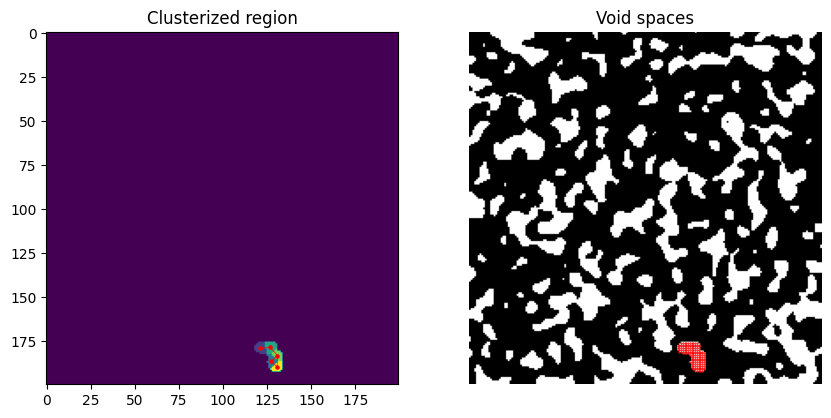

Número de ligações: 5


In [221]:
import random
import matplotlib.pyplot as plt

# Comprimento da lista resultados_kmeans
length = len(resultados_kmeans)

# Gerar um número aleatório entre 0 e length-1
random_index = random.randint(0, length - 1)

# Gerar um número aleatório entre 0 e o comprimento da lista de resultados - 1
random_number_kmean = random_index
#random_number_kmean = 0
numero_de_elementos_na_região = np.count_nonzero(resultados_kmeans[random_number_kmean])
print("Random number_kmean:", random_number_kmean, numero_de_elementos_na_região, 'number_of_pores', number_of_pores_kmeans[random_number])
# Obter a região clusterizada aleatória e seus centros
regiao_aleatoria = resultados_kmeans[random_number_kmean]
centros = coordenadas_centros_kmeans[random_number_kmean]

# Definir uma distância máxima entre centros para considerá-los lado a lado
##distancia_maxima = 5.5  # Ajuste conforme necessário

# Inicializar uma figura
plt.figure(figsize=(10, 10))

# Plotar a região clusterizada
plt.subplot(121)
plt.imshow(regiao_aleatoria)
plt.title('Clusterized region')
# Plotar os centros dos clusters
for centro in centros:
    plt.scatter(centro[1], centro[0], color='red', marker='o', s=5)

# Função para calcular a distância entre dois pontos
def distancia_entre_pontos(p1, p2):
    return ((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)**0.5

# Ligando os centros dos clusters de regiões lado a lado
# Inicialize uma variável para contar o número de ligações
numero_de_ligacoes = 0
for i in range(len(centros)):
    for j in range(i + 1, len(centros)):
        distancia = distancia_entre_pontos(centros[i], centros[j])
        if distancia <= distancia_maxima:
            plt.plot([centros[i][1], centros[j][1]], [centros[i][0], centros[j][0]], 'r-', linewidth=0.5)  # 'r-' para uma linha vermelha
            numero_de_ligacoes += 1

# Exemplo de acesso a uma região segmentada e suas coordenadas
indice_da_regiao = random_number_kmean  # Índice da região desejada
regiao_segmentada_desejada = regioes_segmentadas[indice_da_regiao]
coordenadas_da_regiao_desejada = coordenadas_poros[indice_da_regiao]
plt.subplot(122)
plt.imshow(im, cmap='gray')
plt.plot(coordenadas_da_regiao_desejada[0], coordenadas_da_regiao_desejada[1], 'r.', markersize=1)
plt.title('Void spaces')
plt.axis('off')

# Mostrar o gráfico


plt.show()
# Exibir o número de ligações
print("Número de ligações:", numero_de_ligacoes)

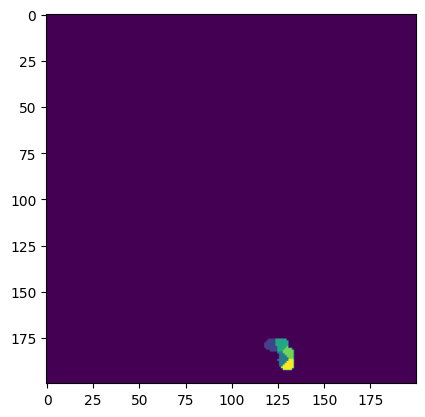

In [222]:
plt.imshow(regiao_aleatoria)

In [227]:
regiao_aleatoria

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

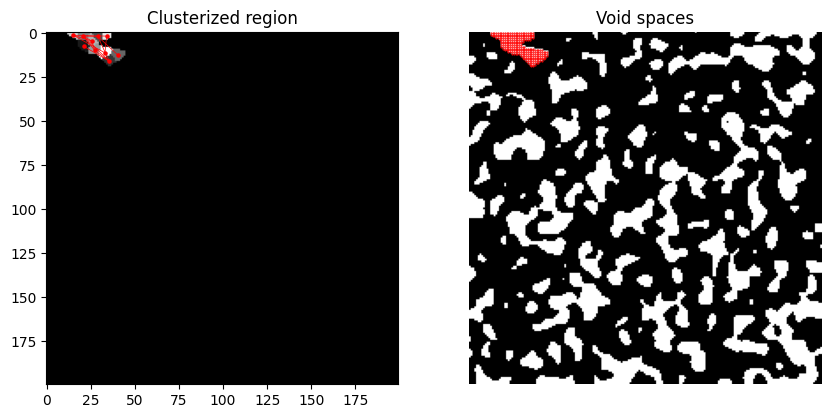

Número de ligações: 13


In [162]:
# import random
# import numpy as np
# import matplotlib.pyplot as plt
# from skimage.measure import label, find_contours
# from scipy.spatial.distance import cdist

# # Função para rotular clusters e encontrar seus contornos
# def obter_contornos_dos_clusters(resultados_kmeans):
#     contornos_por_regiao = []

#     for regiao_clusterizada in resultados_kmeans:
#         # Rotular cada cluster na região
#         labeled_clusters = label(regiao_clusterizada)
#         num_clusters = labeled_clusters.max()
        
#         # Lista para armazenar contornos dos clusters na região atual
#         contornos_da_regiao = []
        
#         for cluster_num in range(1, num_clusters + 1):
#             # Obter uma máscara do cluster atual
#             mask = (labeled_clusters == cluster_num)
#             # Encontrar contornos do cluster atual
#             contornos = find_contours(mask, 0.5)
#             if contornos:  # Adicionar contornos apenas se houver algum
#                 contornos_da_regiao.append(contornos)
        
#         contornos_por_regiao.append(contornos_da_regiao)

#     return contornos_por_regiao

# # Função para calcular a distância mínima entre dois contornos
# def distancia_minima_entre_contornos(contorno1, contorno2):
#     pontos_contorno1 = np.vstack(contorno1)
#     pontos_contorno2 = np.vstack(contorno2)
#     distancias = cdist(pontos_contorno1, pontos_contorno2)
#     return distancias.min()

# # Comprimento da lista resultados_kmeans
# length = len(resultados_kmeans)

# # Obter os contornos de todos os clusters em todas as regiões clusterizadas
# contornos_por_regiao = obter_contornos_dos_clusters(resultados_kmeans)

# # Definir o número da região clusterizada (pode ser um número aleatório ou fixo)
# random_number_kmean = 0

# # Obter a região clusterizada aleatória e seus centros
# regiao_aleatoria = resultados_kmeans[random_number_kmean]
# centros = coordenadas_centros_kmeans[random_number_kmean]
# contornos_da_regiao = contornos_por_regiao[random_number_kmean]

# # Inicializar uma figura
# plt.figure(figsize=(10, 10))

# # Plotar a região clusterizada
# plt.subplot(121)
# plt.imshow(regiao_aleatoria, cmap='gray')
# plt.title('Clusterized region')

# # Plotar os centros dos clusters
# for centro in centros:
#     plt.scatter(centro[1], centro[0], color='red', marker='o', s=5)

# # Inicialize uma variável para contar o número de ligações
# numero_de_ligacoes = 0

# # Ligar centros de clusters cujos contornos têm distância zero
# for i in range(len(centros)):
#     for j in range(i + 1, len(centros)):
#         # Calcular a distância mínima entre os contornos dos clusters i e j
#         min_dist = distancia_minima_entre_contornos(contornos_da_regiao[i][0], contornos_da_regiao[j][0])
#         if min_dist == 0:
#             plt.plot([centros[i][1], centros[j][1]], [centros[i][0], centros[j][0]], 'r-', linewidth=0.5)
#             numero_de_ligacoes += 1

# # Exemplo de acesso a uma região segmentada e suas coordenadas
# indice_da_regiao = random_number_kmean  # Índice da região desejada
# regiao_segmentada_desejada = regioes_segmentadas[indice_da_regiao]
# coordenadas_da_regiao_desejada = coordenadas_poros[indice_da_regiao]
# plt.subplot(122)
# plt.imshow(im, cmap='gray')
# plt.plot(coordenadas_da_regiao_desejada[0], coordenadas_da_regiao_desejada[1], 'r.', markersize=1)
# plt.title('Void spaces')
# plt.axis('off')

# # Mostrar o gráfico
# plt.show()

# # Exibir o número de ligações
# print("Número de ligações:", numero_de_ligacoes)


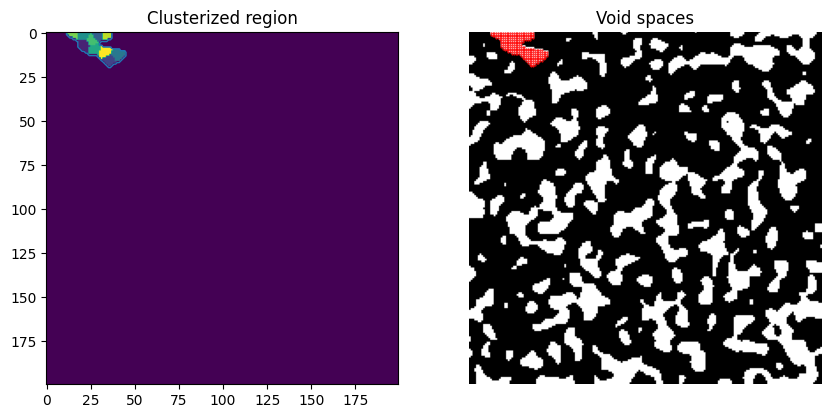

In [103]:
import random
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import find_contours

# Comprimento da lista resultados_kmeans
length = len(resultados_kmeans)

# Gerar um número aleatório entre 0 e length-1
random_index = random.randint(0, length - 1)

# Definir o número da região clusterizada
random_number_kmean = 0

# Obter a região clusterizada aleatória e seus centros
regiao_aleatoria = resultados_kmeans[random_number_kmean]

# Obter os contornos da região clusterizada
contornos = find_contours(regiao_aleatoria, 0.5)  # 0.5 é o valor do limiar para o contorno

# Inicializar uma figura
plt.figure(figsize=(10, 10))

# Plotar a região clusterizada
plt.subplot(121)
plt.imshow(regiao_aleatoria)
plt.title('Clusterized region')

# Plotar os contornos
for contorno in contornos:
    plt.plot(contorno[:, 1], contorno[:, 0], linewidth=1)

# Exemplo de acesso a uma região segmentada e suas coordenadas
indice_da_regiao = random_number_kmean  # Índice da região desejada
regiao_segmentada_desejada = regioes_segmentadas[indice_da_regiao]
coordenadas_da_regiao_desejada = coordenadas_poros[indice_da_regiao]
plt.subplot(122)
plt.imshow(im, cmap='gray')
plt.plot(coordenadas_da_regiao_desejada[0], coordenadas_da_regiao_desejada[1], 'r.', markersize=1)
plt.title('Void spaces')
plt.axis('off')

# Mostrar o gráfico
plt.show()

In [140]:
contornos

[array([[199. , 140.5],
        [198. , 140.5],
        [197.5, 141. ],
        [197. , 141.5],
        [196.5, 142. ],
        [196.5, 143. ],
        [196.5, 144. ],
        [196.5, 145. ],
        [196.5, 146. ],
        [196.5, 147. ],
        [197. , 147.5],
        [197.5, 148. ],
        [198. , 148.5],
        [199. , 148.5]])]

In [104]:
# import random
# import numpy as np
# import matplotlib.pyplot as plt
# from skimage.measure import find_contours

# # Comprimento da lista resultados_kmeans
# length = len(resultados_kmeans)

# # Definir o número da região clusterizada
# random_number_kmean = 0

# # Obter a região clusterizada aleatória e seus centros
# regiao_aleatoria = resultados_kmeans[random_number_kmean]

# # Obter os contornos da região clusterizada
# contornos = find_contours(regiao_aleatoria, 0.5)  # 0.5 é o valor do limiar para o contorno

# # Lista para armazenar os contornos de cada região clusterizada
# contornos_por_regiao = []

# # Adicionar os contornos à lista de contornos da região atual
# contornos_por_regiao.append(contornos)

# # Agora, contornos_por_regiao[0] contém os contornos da primeira região clusterizada

# # Se você quiser salvar os contornos de todas as regiões clusterizadas, você pode colocar o código acima em um loop:

# contornos_por_regiao = []

# for i in range(length):
#     regiao = resultados_kmeans[i]
#     contornos = find_contours(regiao, 0.5)
#     contornos_por_regiao.append(contornos)

# # Agora, contornos_por_regiao[i] contém os contornos da região clusterizada número i

# # Exemplo de como acessar os contornos de uma região específica (por exemplo, a região random_number_kmean)
# contornos_da_regiao_especifica = contornos_por_regiao[random_number_kmean]

# # Agora, contornos_da_regiao_especifica contém os contornos da região clusterizada aleatória


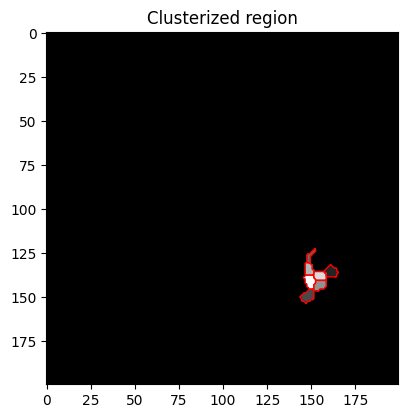

In [160]:
import random
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, find_contours

# Função para rotular clusters e encontrar seus contornos
def obter_contornos_dos_clusters(resultados_kmeans):
    contornos_por_regiao = []

    for regiao_clusterizada in resultados_kmeans:
        # Rotular cada cluster na região
        labeled_clusters = label(regiao_clusterizada)
        num_clusters = labeled_clusters.max()
        
        # Lista para armazenar contornos dos clusters na região atual
        contornos_da_regiao = []
        
        for cluster_num in range(1, num_clusters + 1):
            # Obter uma máscara do cluster atual
            mask = (labeled_clusters == cluster_num)
            # Encontrar contornos do cluster atual
            contornos = find_contours(mask, 0.5)
            contornos_da_regiao.append(contornos)
        
        contornos_por_regiao.append(contornos_da_regiao)

    return contornos_por_regiao

# Comprimento da lista resultados_kmeans
length = len(resultados_kmeans)

# Obter os contornos de todos os clusters em todas as regiões clusterizadas
contornos_por_regiao = obter_contornos_dos_clusters(resultados_kmeans)

# Gerar um índice aleatório para escolher uma região clusterizada
random_index = random.randint(0, length - 1)

# Obter contornos da região clusterizada aleatória
contornos_aleatorios = contornos_por_regiao[random_index]

# Inicializar uma figura
plt.figure(figsize=(10, 10))

# Plotar a região clusterizada aleatória
plt.subplot(121)
plt.imshow(resultados_kmeans[random_index], cmap='gray')
plt.title('Clusterized region')

# Plotar os contornos dos clusters na região clusterizada aleatória
for contorno_cluster in contornos_aleatorios:
    for contorno in contorno_cluster:
        plt.plot(contorno[:, 1], contorno[:, 0], 'r-', linewidth=1)  # 'r-' para uma linha vermelha

# Mostrar o gráfico
plt.show()

In [106]:
len(contornos_da_regiao_especifica), len(contornos_por_regiao)

(1, 118)

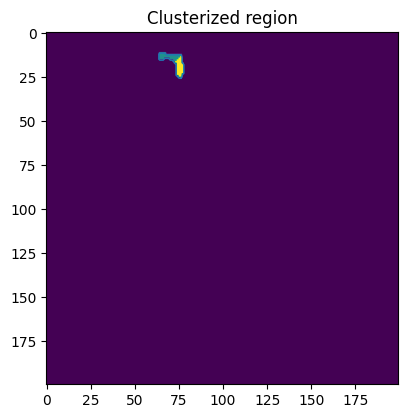

In [153]:
import random
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import find_contours

# Comprimento da lista resultados_kmeans
length = len(resultados_kmeans)

# Gerar um número aleatório entre 0 e length-1
random_index = random.randint(0, length - 1)

# Definir o número da região clusterizada
random_number_kmean = random_index

# Obter a região clusterizada aleatória e seus centros
regiao_aleatoria = resultados_kmeans[random_number_kmean]

# Obter os contornos da região clusterizada
#contornos = find_contours(regiao_aleatoria, 0.5)  # 0.5 é o valor do limiar para o contorno
contornos = contornos_por_regiao[random_number_kmean]
# Inicializar uma figura
plt.figure(figsize=(10, 10))

# Plotar a região clusterizada
plt.subplot(121)
plt.imshow(regiao_aleatoria)
plt.title('Clusterized region')

# Plotar os contornos
for contorno in contornos:
    plt.plot(contorno[:, 1], contorno[:, 0], linewidth=1)


In [ ]:
len(contornos_por_regiao)

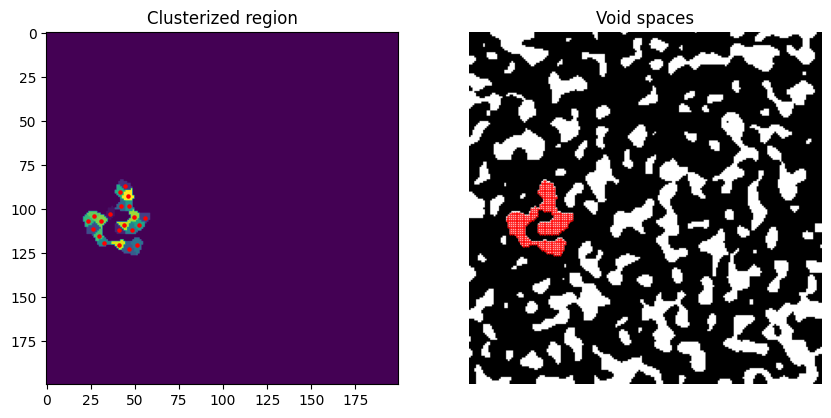

Número de ligações: 0


In [95]:
import random
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import binary_erosion

# Função para calcular a área de sobreposição entre duas regiões
def calcular_area_sobreposicao(borda1, borda2):
    area = 0
    for p1 in borda1:
        for p2 in borda2:
            if np.array_equal(p1, p2):  # Verificar se os pixels são os mesmos
                area += 1
                break
    return area

# Supondo que resultados_kmeans, coordenadas_centros_kmeans, regioes_segmentadas,
# coordenadas_poros, binary_image, e number_of_pores_kmeans estejam definidos previamente

# Comprimento da lista resultados_kmeans
length = len(resultados_kmeans)

# Gerar um número aleatório entre 0 e length-1
random_index = random.randint(0, length - 1)

# Gerar um número aleatório entre 0 e o comprimento da lista de resultados - 1
random_number_kmean = random_index

# Obter a região clusterizada aleatória e seus centros
regiao_aleatoria = resultados_kmeans[random_number_kmean]
centros = coordenadas_centros_kmeans[random_number_kmean]

# Inicializar uma figura
plt.figure(figsize=(10, 10))

# Plotar a região clusterizada
plt.subplot(121)
plt.imshow(regiao_aleatoria)
plt.title('Clusterized region')

# Plotar os centros dos clusters
for centro in centros:
    plt.scatter(centro[1], centro[0], color='red', marker='o', s=5)

# Inicialize uma variável para contar o número de ligações
numero_de_ligacoes = 0

# Lista para armazenar os vetores trajetórias
vetores_trajetorias = []

# Variável para armazenar a maior trajetória
maior_trajetoria = (None, None, 0)  # (ponto inicial, ponto final, comprimento)

# Obter as bordas de todas as regiões
bordas = [obter_borda(resultados_kmeans[i]) for i in range(length)]

# Definir um limiar para a área de sobreposição
limiar_sobreposicao = 1  # Ajuste conforme necessário

for i in range(len(centros)):
    for j in range(i + 1, len(centros)):
        # Calcular a área de sobreposição entre as bordas dos clusters i e j
        area_sobreposicao = calcular_area_sobreposicao(bordas[i], bordas[j])
        if area_sobreposicao > limiar_sobreposicao:
            # Conectar os centros dos clusters
            plt.plot([centros[i][1], centros[j][1]], [centros[i][0], centros[j][0]], 'r-', linewidth=0.5)
            numero_de_ligacoes += 1

# Exemplo de acesso a uma região segmentada e suas coordenadas
indice_da_regiao = random_number_kmean  # Índice da região desejada
regiao_segmentada_desejada = regioes_segmentadas[indice_da_regiao]
coordenadas_da_regiao_desejada = coordenadas_poros[indice_da_regiao]
plt.subplot(122)
plt.imshow(binary_image, cmap='gray')
plt.plot(coordenadas_da_regiao_desejada[0], coordenadas_da_regiao_desejada[1], 'r.', markersize=1)
plt.title('Void spaces')
plt.axis('off')

# Mostrar o gráfico
plt.show()

# Exibir o número de ligações
print("Número de ligações:", numero_de_ligacoes)

Random number_kmean: 49 314 number_of_pores 1


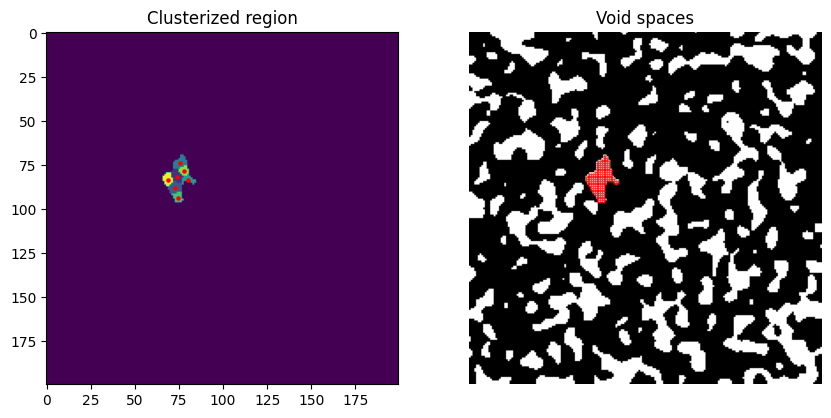

Número de ligações: 0


In [89]:
import random
import matplotlib.pyplot as plt

# Comprimento da lista resultados_kmeans
length = len(resultados_kmeans)

# Gerar um número aleatório entre 0 e length-1
random_index = random.randint(0, length - 1)

# Gerar um número aleatório entre 0 e o comprimento da lista de resultados - 1
random_number_kmean = random_index
numero_de_elementos_na_regiao = np.count_nonzero(resultados_kmeans[random_number_kmean])
print("Random number_kmean:", random_number_kmean, numero_de_elementos_na_região, 'number_of_pores', number_of_pores_kmeans[random_number])

# Obter a região clusterizada aleatória e seus centros
regiao_aleatoria = resultados_kmeans[random_number_kmean]
centros = coordenadas_centros_kmeans[random_number_kmean]

# Inicializar uma figura
plt.figure(figsize=(10, 10))

# Plotar a região clusterizada
plt.subplot(121)
plt.imshow(regiao_aleatoria)
plt.title('Clusterized region')

# Plotar os centros dos clusters
for centro in centros:
    plt.scatter(centro[1], centro[0], color='red', marker='o', s=5)

# Inicialize uma variável para contar o número de ligações
numero_de_ligacoes = 0

# Lista para armazenar os vetores trajetórias
vetores_trajetorias = []

# Variável para armazenar a maior trajetória
maior_trajetoria = (None, None, 0)  # (ponto inicial, ponto final, comprimento)

# Identificar regiões clusterizadas adjacentes e conectar seus centros
for i in range(length - 1):
    regiao_atual = resultados_kmeans[i]
    regiao_proxima = resultados_kmeans[i + 1]
    # Verificar se as regiões atuais são adjacentes
    if np.any(regiao_atual & regiao_proxima):
        # Conectar os centros dos clusters das regiões adjacentes
        centros_atual = coordenadas_centros_kmeans[i]
        centros_proxima = coordenadas_centros_kmeans[i + 1]
        for centro_atual in centros_atual:
            for centro_proxima in centros_proxima:
                plt.plot([centro_atual[1], centro_proxima[1]], [centro_atual[0], centro_proxima[0]], 'r-', linewidth=0.5)
                numero_de_ligacoes += 1

# Exemplo de acesso a uma região segmentada e suas coordenadas
indice_da_regiao = random_number_kmean  # Índice da região desejada
regiao_segmentada_desejada = regioes_segmentadas[indice_da_regiao]
coordenadas_da_regiao_desejada = coordenadas_poros[indice_da_regiao]
plt.subplot(122)
plt.imshow(im, cmap='gray')
plt.plot(coordenadas_da_regiao_desejada[0], coordenadas_da_regiao_desejada[1], 'r.', markersize=1)
plt.title('Void spaces')
plt.axis('off')

# Mostrar o gráfico
plt.show()

# Exibir o número de ligações
print("Número de ligações:", numero_de_ligacoes)

In [90]:
regiao_aleatoria.max()

7

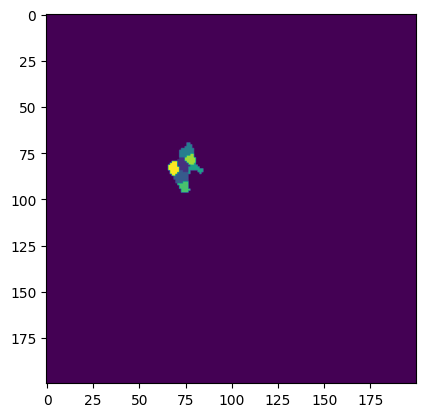

In [91]:
plt.imshow(regiao_aleatoria)

In [92]:
# The criteria of the connected regions is that if there is an intersection between two regions, then
# They are connected.

In [93]:
len(resultados_kmeans)

118

In [94]:
min(ratio_of_aspect_cluster_kmeans), max(ratio_of_aspect_cluster_kmeans)

([0], [1.0])

## Estimating the tortuosity with the equation:
$\tau=\frac{l}{r}$


Where l is the distance of the trajetory and r is the the distance between the initial point and final.

Random number_kmean: 49 314 number_of_pores 1


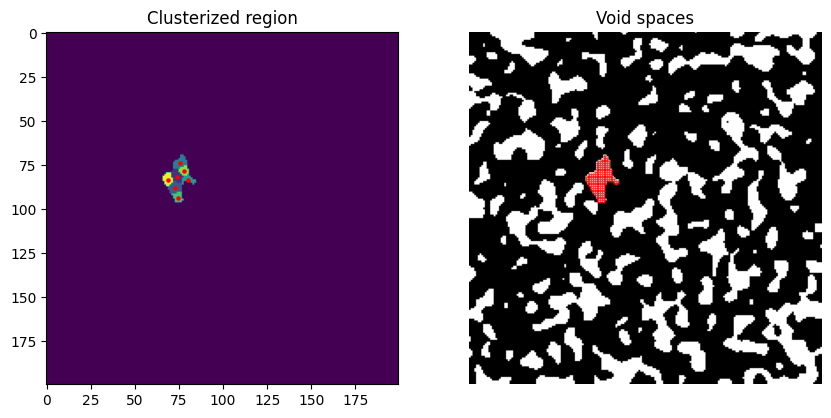

Número de ligações: 0
Vetores trajetórias: []


## K means: Plot the ratio of aspect, Number of connections x void  and spaces and Number of pores x void spaces 

In [13]:
len(ratio_of_aspect_cluster_kmeans)

118

In [14]:
from itertools import chain

In [15]:
# Utilizando itertools.chain para "descompactar" todas as listas internas em uma única lista
all_aspect_ratios_kmeans = list(chain(*ratio_of_aspect_cluster_kmeans))

In [16]:
len(all_aspect_ratios_kmeans)

376

In [17]:
count_spherical_pores_kmeans = len(list(filter(lambda x: x == 1, all_aspect_ratios_kmeans)))

Number of pores that are spherical: 2


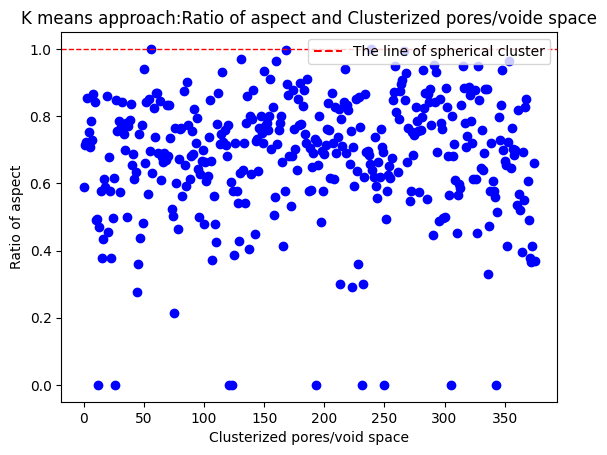

In [18]:
print('Number of pores that are spherical:', count_spherical_pores_kmeans)
# Plotar os pontos (void space no eixo x e número de ligações no eixo y)
plt.plot(all_aspect_ratios_kmeans, 'bo')

# Adicionar uma linha horizontal ao longo do valor zero no eixo y
plt.axhline(1, color='red', linestyle='--', linewidth=1)

# Adicionar uma linha separada com a mesma cor e estilo para a legenda
plt.plot([], [], color='red', linestyle='--', label='The line of spherical cluster')

# Adicionar a legenda
plt.legend()

# Adicionar rótulos aos eixos
plt.xlabel('Clusterized pores/void space')
plt.ylabel('Ratio of aspect')
plt.title('K means approach:Ratio of aspect and Clusterized pores/voide space')
plt.show()

In [19]:
import random
import matplotlib.pyplot as plt

# Lista para armazenar o número de ligações para cada região clusterizada
numero_de_ligacoes_por_regiao_kmeans = []

# Iterar sobre as regiões clusterizadas
for i in range(len(resultados_kmeans)):
    # Obter a região clusterizada atual e seus centros
    regiao = resultados_kmeans[i]
    centros = coordenadas_centros_kmeans[i]

    # Definir uma distância máxima entre centros para considerá-los lado a lado
    ##distancia_maxima = 5  # Ajuste conforme necessário

    # Inicializar uma variável para contar o número de ligações para esta região
    numero_de_ligacoes_kmeans = 0

    # Ligando os centros dos clusters de regiões lado a lado
    for i in range(len(centros)):
        for j in range(i + 1, len(centros)):
            distancia = distancia_entre_pontos(centros[i], centros[j])
            if distancia <= distancia_maxima:
                numero_de_ligacoes_kmeans += 1

    # Adicionar o número de ligações para esta região à lista
    numero_de_ligacoes_por_regiao_kmeans.append(numero_de_ligacoes_kmeans)

# Exibir a lista de número de ligações para cada região clusterizada
##print(numero_de_ligacoes_por_regiao_kmeans)



In [20]:
len(number_of_pores_kmeans), len(numero_de_ligacoes_por_regiao_kmeans)

(118, 118)

Number of isolated pores: 77


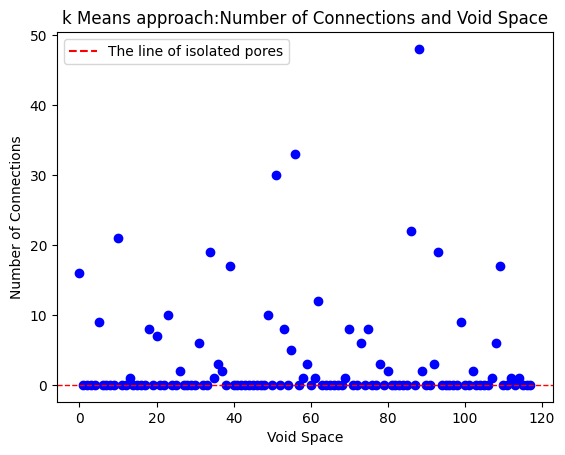

In [21]:
import matplotlib.pyplot as plt
count_zeros_lig_kmeans = len(list(filter(lambda x: x == 0, numero_de_ligacoes_por_regiao_kmeans)))
print(f"Number of isolated pores: {count_zeros_lig_kmeans}")
# Plotar os pontos (void space no eixo x e número de ligações no eixo y)
plt.plot(numero_de_ligacoes_por_regiao_kmeans, 'bo')

# Adicionar uma linha horizontal ao longo do valor zero no eixo y
plt.axhline(0, color='red', linestyle='--', linewidth=1)

# Adicionar uma linha separada com a mesma cor e estilo para a legenda
plt.plot([], [], color='red', linestyle='--', label='The line of isolated pores')

# Adicionar a legenda
plt.legend()

# Adicionar rótulos aos eixos
plt.xlabel('Void Space')
plt.ylabel('Number of Connections')
plt.title('k Means approach:Number of Connections and Void Space')
plt.show()

Number of void space without pores: 0


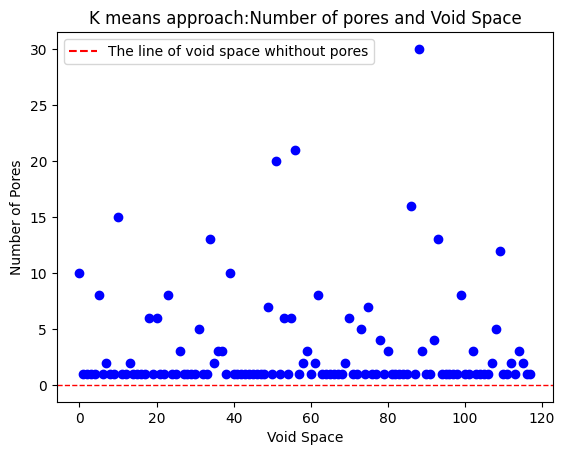

In [22]:
count_zeros_kmeans = len(list(filter(lambda x: x == 0, number_of_pores_kmeans)))
print(f"Number of void space without pores: {count_zeros_kmeans}")

# Plotar os pontos
plt.plot(number_of_pores_kmeans, 'bo')

# Adicionar uma linha horizontal ao longo do valor zero no eixo y
plt.axhline(0, color='red', linestyle='--', linewidth=1)

# Adicionar uma linha separada com a mesma cor e estilo para a legenda
plt.plot([], [], color='red', linestyle='--', label='The line of void space whithout pores')

# Adicionar a legenda
plt.legend()

# Adicionar rótulos aos eixos
plt.xlabel('Void Space')
plt.ylabel('Number of Pores')
plt.title('K means approach:Number of pores and Void Space')
plt.show()

## Apply the Gaussian Mixture 

In [51]:
import numpy as np
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
from skimage.measure import regionprops, label

def apply_gmm_to_region(region_segmentada, pore_number):
    # Obter os pixels que são representados por 1 na região segmentada
    pixels_0 = np.argwhere(region_segmentada == 1)

    # Verificar se há pixels suficientes para aplicar o GMM
    if len(pixels_0) < 2:
        return region_segmentada, 0, np.empty((0, 2))

    # Determinar o número de vezes que len(pixels_0) excede pore_number
    excessos = len(pixels_0) // pore_number

    # Ajustar o número de clusters com base nos excessos
    num_clusters = max(1, excessos)

    # Aplicar Gaussian Mixture Model aos pixels 0 para segmentá-los em clusters
    gmm = GaussianMixture(n_components=num_clusters, random_state=42)
    gmm.fit(pixels_0)

    # Obter os rótulos dos clusters atribuídos aos pixels 0
    labels = gmm.predict(pixels_0)

    # Criar uma matriz com os rótulos dos clusters nas posições dos pixels 0
    clustered_region = np.zeros_like(region_segmentada)
    for label, pixel in zip(labels, pixels_0):
        clustered_region[pixel[0], pixel[1]] = label + 1  # Adicionar 1 para evitar label 0

    # Calcular os centros dos clusters
    cluster_centers = gmm.means_

    # Retornar a região clusterizada, o número de clusters e as coordenadas dos centros dos clusters
    return clustered_region, num_clusters, cluster_centers

# Lista para armazenar as coordenadas dos centros de cada região clusterizada
coordenadas_centros_gm = []
resultados_gmm = []
number_of_pores_gm = []
ratio_of_aspect_cluster_gm = []

# Exemplo de lista de regiões segmentadas
#regioes_segmentadas = [np.random.randint(0, 2, size=(100, 100)) for _ in range(5)]
#pore_number = 10

# Plotar as regiões segmentadas após a aplicação do GMM
#plt.figure(figsize=(15, 10))
for i, region_segmentada in enumerate(regioes_segmentadas, start=1):
    # Aplicar o GMM à região segmentada atual
    clustered_region_gm, n_por_gm, centros_gm = apply_gmm_to_region(region_segmentada, pore_number)

    # Armazenar as coordenadas dos centros dos clusters na lista
    coordenadas_centros_gm.append(centros_gm)
    resultados_gmm.append(clustered_region_gm)
    number_of_pores_gm.append(n_por_gm)

    # Calcular as razões de aspecto dos clusters
    aspect_ratios_gm = calculate_aspect_ratios(clustered_region_gm)
    ratio_of_aspect_cluster_gm.append(aspect_ratios_gm)

<Figure size 1500x1000 with 0 Axes>

## Gaussian mixture: Plot the ratio of aspect, Number of connections x void  and spaces and Number of pores x void spaces 

In [52]:
len(ratio_of_aspect_cluster_gm)

113

In [54]:
from itertools import chain
# Utilizando itertools.chain para "descompactar" todas as listas internas em uma única lista
all_aspect_ratios_gm = list(chain(*ratio_of_aspect_cluster_gm))

In [55]:
len(all_aspect_ratios_gm)

380

In [56]:
count_spherical_pores_gm = len(list(filter(lambda x: x == 1, all_aspect_ratios_gm)))

Number of pores that are spherical: 1


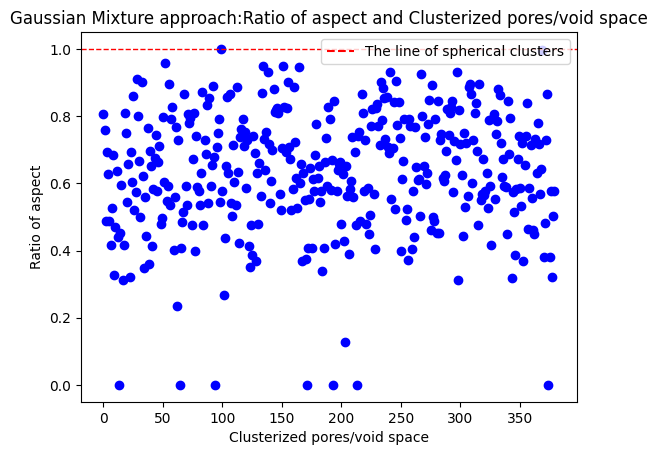

In [57]:
print('Number of pores that are spherical:', count_spherical_pores_gm)
# Plotar os pontos (void space no eixo x e número de ligações no eixo y)
plt.plot(all_aspect_ratios_gm, 'bo')

# Adicionar uma linha horizontal ao longo do valor zero no eixo y
plt.axhline(1, color='red', linestyle='--', linewidth=1)

# Adicionar uma linha separada com a mesma cor e estilo para a legenda
plt.plot([], [], color='red', linestyle='--', label='The line of spherical clusters')

# Adicionar a legenda
plt.legend()

# Adicionar rótulos aos eixos
plt.xlabel('Clusterized pores/void space')
plt.ylabel('Ratio of aspect')
plt.title('Gaussian Mixture approach:Ratio of aspect and Clusterized pores/void space')
plt.show()

In [58]:
import random
import matplotlib.pyplot as plt

# Lista para armazenar o número de ligações para cada região clusterizada
numero_de_ligacoes_por_regiao_gm = []

# Iterar sobre as regiões clusterizadas
for i in range(len(resultados_gmm)):
    # Obter a região clusterizada atual e seus centros
    regiao = resultados_gmm[i]
    centros = coordenadas_centros_gm[i]

    # Definir uma distância máxima entre centros para considerá-los lado a lado
    #distancia_maxima = 5  # Ajuste conforme necessário

    # Inicializar uma variável para contar o número de ligações para esta região
    numero_de_ligacoes_gm = 0

    # Ligando os centros dos clusters de regiões lado a lado
    for i in range(len(centros)):
        for j in range(i + 1, len(centros)):
            distancia = distancia_entre_pontos(centros[i], centros[j])
            if distancia <= distancia_maxima:
                numero_de_ligacoes_gm += 1

    # Adicionar o número de ligações para esta região à lista
    numero_de_ligacoes_por_regiao_gm.append(numero_de_ligacoes_gm)

# Exibir a lista de número de ligações para cada região clusterizada
print(numero_de_ligacoes_por_regiao_gm)



[4, 5, 7, 0, 23, 0, 0, 40, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 21, 0, 1, 0, 0, 0, 0, 0, 15, 1, 0, 0, 2, 1, 0, 0, 15, 50, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 5, 8, 0, 0, 1, 0, 5, 16, 0, 0, 4, 0, 3, 25, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 3, 0, 0, 0, 6, 0, 38, 34, 0, 0, 20, 0, 0, 6, 1, 0, 0, 0, 0, 0, 0, 6, 10, 0, 1, 1, 0, 0, 0, 0, 0, 0]


Number of void spaces without pores: 3


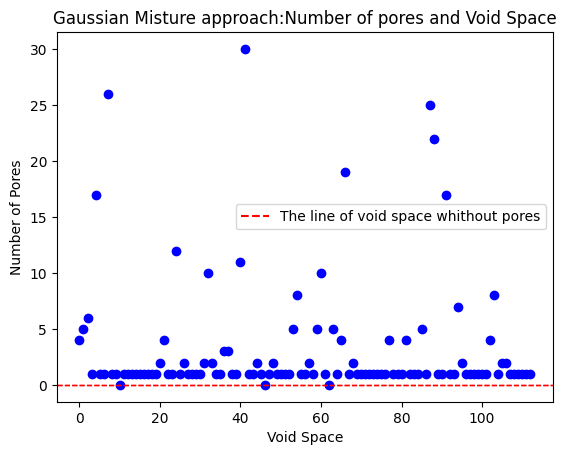

In [60]:
count_zeros_gm = len(list(filter(lambda x: x == 0, number_of_pores_gm)))
print(f"Number of void spaces without pores: {count_zeros_gm}")
# Plotar os pontos
plt.plot(number_of_pores_gm, 'bo')

# Adicionar uma linha horizontal ao longo do valor zero no eixo y
plt.axhline(0, color='red', linestyle='--', linewidth=1)

# Adicionar uma linha horizontal ao longo do valor zero no eixo y
plt.axhline(0, color='red', linestyle='--', linewidth=1)

# Adicionar uma linha separada com a mesma cor e estilo para a legenda
plt.plot([], [], color='red', linestyle='--', label='The line of void space whithout pores')

plt.legend()
# Adicionar rótulos aos eixos
plt.xlabel('Void Space')
plt.ylabel('Number of Pores')
plt.title('Gaussian Misture approach:Number of pores and Void Space')
plt.show()

Number of isolated pores: 75


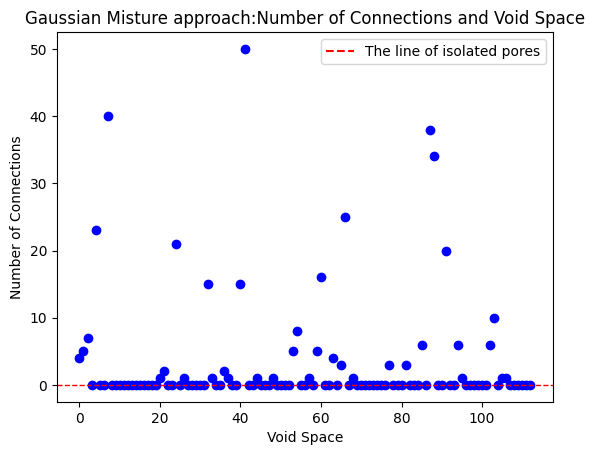

In [61]:
count_zeros_lig_gm = len(list(filter(lambda x: x == 0, numero_de_ligacoes_por_regiao_gm)))

print(f"Number of isolated pores: {count_zeros_lig_gm}")
import matplotlib.pyplot as plt

# Plotar os pontos (void space no eixo x e número de ligações no eixo y)
plt.plot(numero_de_ligacoes_por_regiao_gm, 'bo')

# Adicionar uma linha horizontal ao longo do valor zero no eixo y
plt.axhline(0, color='red', linestyle='--', linewidth=1)

# Adicionar uma linha separada com a mesma cor e estilo para a legenda
plt.plot([], [], color='red', linestyle='--', label='The line of isolated pores')

# Adicionar a legenda
plt.legend()

# Adicionar rótulos aos eixos
plt.xlabel('Void Space')
plt.ylabel('Number of Connections')
plt.title('Gaussian Misture approach:Number of Connections and Void Space')
plt.show()

In [62]:
height, width = im.shape

In [63]:
height, width

(200, 200)

In [64]:
pixel_area = 1
total_area = height * width

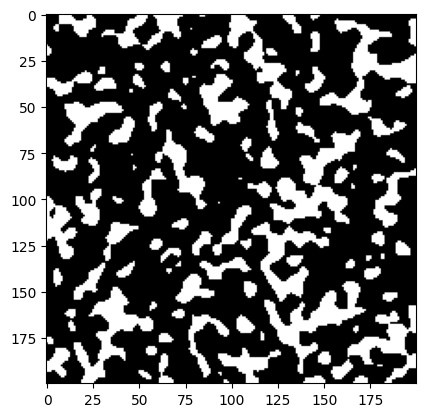

In [65]:
plt.imshow(binary_image, cmap='gray')

In [66]:
binary_image.min(), binary_image.max()

(False, True)

In [67]:
binary_image = binary_image.astype('uint8')

In [68]:
# When you set the pore to be the value 1 # background 
# You are suppose to use the calculate_pore_properties_gray_version_rock to calculate the properties
import numpy as np

def calculate_pore_properties_gray_version_rock(segmented_image, pixel_area, total_area):
    """
    Calculate pore properties including pore area and porosity for a grayscale segmented image.

    Parameters:
    - segmented_image: 2D segmented image where pores are represented by values between 0 and 1.
    - pixel_area: Area of a single pixel in the image.

    Returns:
    - grain_area: Total area of segmented grain regions.
    - fraction_matrix: matrix calculated as the ratio of grain area to the total area.
    """
    # Check if the input image is within the valid range
    if not (np.all(0 <= segmented_image) and np.all(segmented_image <= 1)):
        raise ValueError("Input image must have values between 0 and 1 for grayscale segmentation.")
    # Calculate pore area
    pore_area = np.sum(segmented_image) * pixel_area
    
    # Calculate total area of the image
    #total_area = np.sum(segmented_image >= 0) * pixel_area
    ##total_area = np.sum(segmented_image >= segmented_image.min()) * pixel_area
    ##total_area = circle_area
    # Calculate porosity
    porosity = pore_area / total_area
    fraction_matrix = 1.0 - porosity
    grain_area = total_area - pore_area
    return grain_area, fraction_matrix, porosity, pore_area

In [69]:
grain_area_sinthetic, fraction_matrix_sinthetic, porosity_sinthetic, pore_area_sinthetic = calculate_pore_properties_gray_version_rock(binary_image, pixel_area, total_area) 

In [70]:
print('The grain area:', grain_area_sinthetic,'in pixels')
print('The fraction matrix:', fraction_matrix_sinthetic,'in percentage')
print('The porosity:', porosity_sinthetic,'in percentage')
print('The pore area:', pore_area_sinthetic,'in pixels')

The grain area: 28582 in pixels
The fraction matrix: 0.71455 in percentage
The porosity: 0.28545 in percentage
The pore area: 11418 in pixels


## The tortuosity k means

By the lanfrey Equation (at a 2010)

$\tau=1.23\frac{(1-\phi)^{4/3}}{\xi^{2}\phi}$

Where $\phi$ is the total porosity of the medium, the $\xi$ is the shape factor (Ratio of aspect of each pore).

Link of the reference:https://www.mdpi.com/2227-9717/11/1/3

In [71]:
def calculate_tortuosity_lanfrey(phi, shape_fac_list, tolerance=1e-2):
    tau_list = []
    for shape_fac in shape_fac_list:
        numerator = 1.23 * ((1 - shape_fac)**(4./3.))
        denominator = (phi**2) * shape_fac
        
        # Verificar se o denominador é muito pequeno
        if denominator < tolerance:
            tau = 0  # Anulando o valor de tortuosidade
        else:
            tau = numerator / denominator
        
        tau_list.append(tau)
    return tau_list

In [72]:
#The tortuosity to the model with K means
phi_t = porosity_sinthetic
shape_fac_k_means = all_aspect_ratios_kmeans

In [73]:
min(all_aspect_ratios_kmeans), max(all_aspect_ratios_kmeans)

(0, 1.0)

In [74]:
tortuosity_k_means = calculate_tortuosity_lanfrey(phi_t, shape_fac_k_means)

In [75]:
import statistics

In [76]:
min(tortuosity_k_means), max(tortuosity_k_means)

(0, 44.96005290541876)

In [77]:
mean_tort_k_mean = statistics.mean(tortuosity_k_means)
mean_tort_k_mean

5.438368087872544

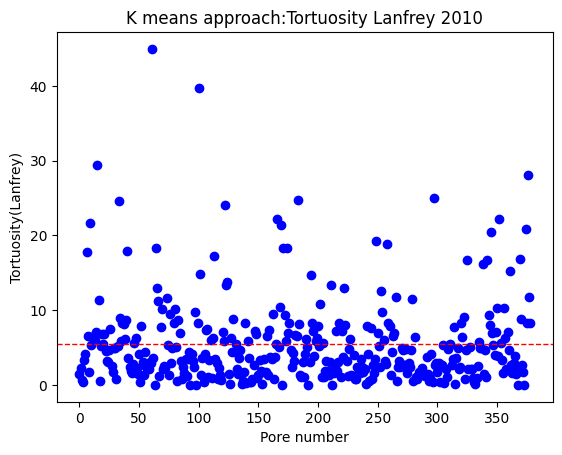

In [78]:
# Plotar os pontos (void space no eixo x e número de ligações no eixo y)
plt.plot(tortuosity_k_means, 'bo')

# Adicionar uma linha horizontal ao longo do valor zero no eixo y
plt.axhline(mean_tort_k_mean, color='red', linestyle='--', linewidth=1)

# Adicionar uma linha separada com a mesma cor e estilo para a legenda
##plt.plot([], [], color='red', linestyle='--', label='The line of isolated pores')

# Adicionar a legenda
##plt.legend()

# Adicionar rótulos aos eixos
plt.xlabel('Pore number')
plt.ylabel('Tortuosity(Lanfrey)')
plt.title('K means approach:Tortuosity Lanfrey 2010')
plt.show()

## The tortuosity Gaussian Mixture

By the lanfrey Equation (at a 2010)

$\tau=1.23\frac{(1-\phi)^{4/3}}{\xi^{2}\phi}$

Where $\phi$ is the total porosity of the medium, the $\xi$ is the shape factor (Ratio of aspect of each pore).

Link of the reference:https://www.mdpi.com/2227-9717/11/1/3

In [85]:
#The tortuosity to the model with K means
phi_t = porosity_sinthetic

In [86]:
min(all_aspect_ratios_gm), max(all_aspect_ratios_gm)

(0, 1.0)

In [87]:
tortuosity_gm = calculate_tortuosity_lanfrey(phi_t, all_aspect_ratios_gm)

In [90]:
import statistics
min(tortuosity_gm), max(tortuosity_gm)

(0, 98.65091709338022)

In [92]:
mean_tort_gm = statistics.mean(tortuosity_gm)
mean_tort_gm

7.662275480089292

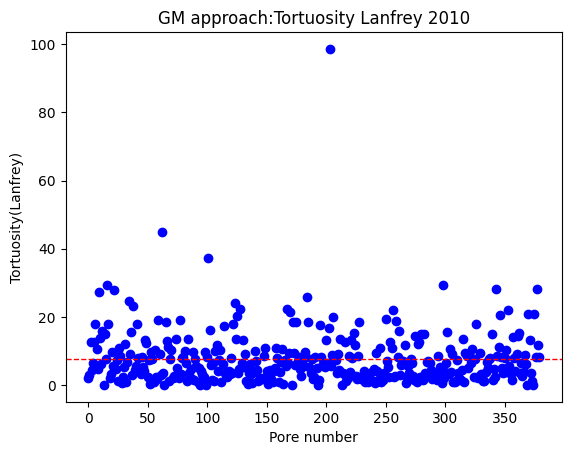

In [94]:
# Plotar os pontos (void space no eixo x e número de ligações no eixo y)
plt.plot(tortuosity_gm, 'bo')

# Adicionar uma linha horizontal ao longo do valor zero no eixo y
plt.axhline(mean_tort_gm, color='red', linestyle='--', linewidth=1)

# Adicionar uma linha separada com a mesma cor e estilo para a legenda
##plt.plot([], [], color='red', linestyle='--', label='The line of isolated pores')

# Adicionar a legenda
##plt.legend()

# Adicionar rótulos aos eixos
plt.xlabel('Pore number')
plt.ylabel('Tortuosity(Lanfrey)')
plt.title('GM approach:Tortuosity Lanfrey 2010')
plt.show()

In [95]:
import cv2
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt
# Load the image
image = cv2.imread('PirabasB_2 - Copy.tif')

# Convert the image to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Convert the grayscale image to a numpy array
image_array = np.array(gray_image)

In [97]:
image_array.shape, gray_image.shape

((768, 1024), (768, 1024))

In [99]:
image_array.dtype, image_array.max(), image_array.min()

(dtype('uint8'), 255, 0)

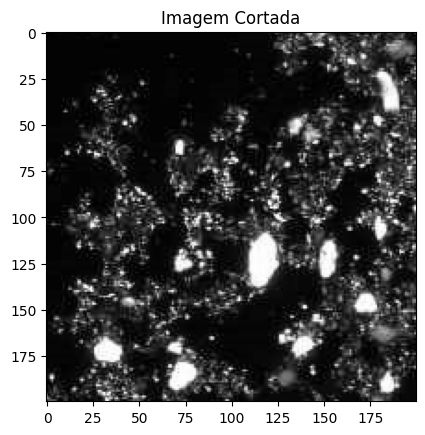

In [141]:
def crop_image(im, crop_height, crop_width, start_row, start_col):
    """
    Corta uma subimagem da imagem original.
    
    Parâmetros:
    im (numpy.ndarray): A imagem original com forma (altura, largura).
    crop_height (int): A altura do corte.
    crop_width (int): A largura do corte.
    start_row (int): A linha inicial para o corte.
    start_col (int): A coluna inicial para o corte.
    
    Retorna:
    numpy.ndarray: A subimagem cortada.
    """
    end_row = start_row + crop_height
    end_col = start_col + crop_width
    
    # Garantir que os limites de corte estejam dentro da imagem original
    if end_row > im.shape[0] or end_col > im.shape[1]:
        raise ValueError("Os limites do corte excedem as dimensões da imagem original")
    
    return im[start_row:end_row, start_col:end_col]

# Exemplo de uso
#im = np.random.rand(768, 1024, 3)  # Imagem de exemplo com valores aleatórios

crop_height = 200  # Altura do corte desejado
crop_width = 200   # Largura do corte desejado
start_row = 100    # Linha inicial para o corte
start_col = 200    # Coluna inicial para o corte

cropped_im = crop_image(image_array, crop_height, crop_width, start_row, start_col)

# Visualização da imagem cortada (opcional)
plt.imshow(cropped_im, cmap='gray')
plt.title("Imagem Cortada")
plt.show()

In [142]:
image_array = cropped_im

In [143]:
# Set the pore to be the value 1
# This function is to create the binary image to the recognition process work
def create_binary(img):    
    import cv2
    # Convert the image to grayscale
    #gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply a threshold to the grayscale image
    #threshold_value = 95
    threshold_value = img.mean() + 0.25 * img.mean()
    #print(threshold_value)
    #threshold_value = slice_0330_image.mean()
    max_value = 1
    # Set the value 1 to be the pore space
    ret, binary = cv2.threshold(img, threshold_value, max_value, cv2.THRESH_BINARY_INV)
    return binary

In [144]:
binary_image = create_binary(image_array)

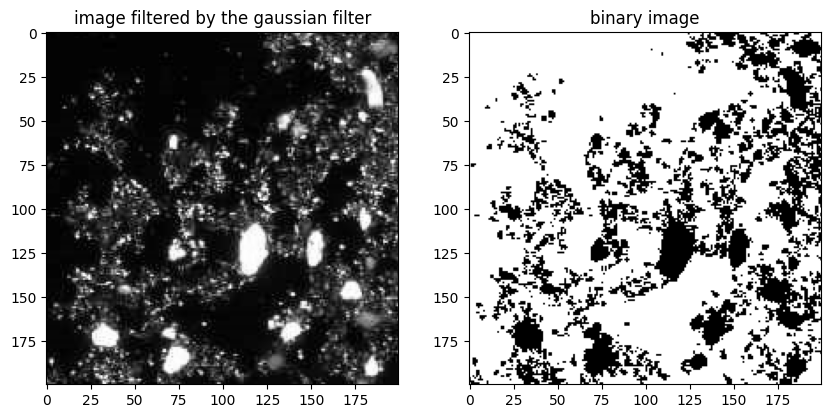

In [145]:
import matplotlib.pyplot as plt
import numpy as np

# Create two sample arrays


# Create a figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Plot the original image
axs[0].imshow(image_array, cmap='gray')
axs[0].set_title('image filtered by the gaussian filter')

# Plot the binary image
axs[1].imshow(binary_image, cmap='gray')
axs[1].set_title('binary image')

# Show the plot
plt.show()

In [146]:
binary_image.shape

(200, 200)

In [147]:
binary_image.dtype, binary_image.min(), binary_image.max()

(dtype('uint8'), 0, 1)

In [148]:
# Label connected components in the binary image
labeled_image, num_labels = ndi.label(binary_image)

In [149]:
# Lista para salvar as regiões segmentadas (void space)
regioes_segmentadas = []

# Lista para salvar as coordenadas de cada região
coordenadas_poros = []

# Iterar sobre os diferentes rótulos de regiões na imagem rotulada
for label in range(1, num_labels + 1):
    # Encontrar os índices dos pixels da região na imagem rotulada
    indices_regiao = np.where(labeled_image == label)

    # Salvar as coordenadas x e y dos pixels da região na imagem original
    coords_x, coords_y = indices_regiao[1], indices_regiao[0]
    coordenadas_poros.append((coords_x, coords_y))

    # Extrair a região segmentada (void space) da imagem original
    regiao_segmentada = np.zeros_like(image_array)
    regiao_segmentada[coords_y, coords_x] = 1  # Atribuir 1 aos pixels da região
    regioes_segmentadas.append(regiao_segmentada)



In [150]:
len(regioes_segmentadas)

200

Random number: 153


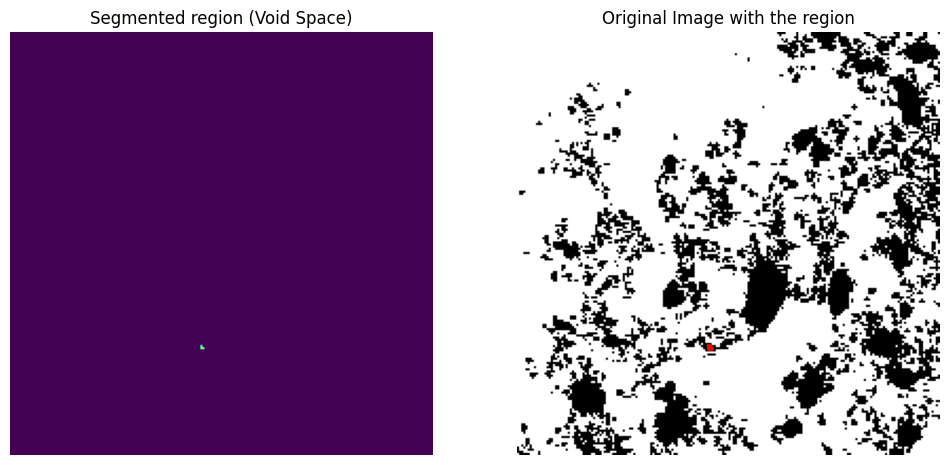

In [151]:
import random
random_number = random.randint(0, len(regioes_segmentadas))  # Generates a random integer between 1 and 100 (inclusive)
print("Random number:", random_number)

# Exemplo de acesso a uma região segmentada e suas coordenadas
indice_da_regiao = random_number  # Índice da região desejada
regiao_segmentada_desejada = regioes_segmentadas[indice_da_regiao]
coordenadas_da_regiao_desejada = coordenadas_poros[indice_da_regiao]



# Visualizar a região segmentada e as coordenadas
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(regiao_segmentada_desejada)
plt.title('Segmented region (Void Space)')
plt.axis('off')

plt.subplot(122)
plt.imshow(binary_image, cmap='gray')
plt.plot(coordenadas_da_regiao_desejada[0], coordenadas_da_regiao_desejada[1], 'r.', markersize=5)
plt.title('Original Image with the region')
plt.axis('off')
plt.show()

## Apply the Gaussian Mixture to the pirabas sample 2

In [152]:
import numpy as np
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
from skimage.measure import regionprops, label

def apply_gmm_to_region(region_segmentada, pore_number):
    # Obter os pixels que são representados por 1 na região segmentada
    pixels_0 = np.argwhere(region_segmentada == 1)

    # Verificar se há pixels suficientes para aplicar o GMM
    if len(pixels_0) < 2:
        return region_segmentada, 0, np.empty((0, 2))

    # Determinar o número de vezes que len(pixels_0) excede pore_number
    excessos = len(pixels_0) // pore_number

    # Ajustar o número de clusters com base nos excessos
    num_clusters = max(1, excessos)

    # Aplicar Gaussian Mixture Model aos pixels 0 para segmentá-los em clusters
    gmm = GaussianMixture(n_components=num_clusters, random_state=42)
    gmm.fit(pixels_0)

    # Obter os rótulos dos clusters atribuídos aos pixels 0
    labels = gmm.predict(pixels_0)

    # Criar uma matriz com os rótulos dos clusters nas posições dos pixels 0
    clustered_region = np.zeros_like(region_segmentada)
    for label, pixel in zip(labels, pixels_0):
        clustered_region[pixel[0], pixel[1]] = label + 1  # Adicionar 1 para evitar label 0

    # Calcular os centros dos clusters
    cluster_centers = gmm.means_

    # Retornar a região clusterizada, o número de clusters e as coordenadas dos centros dos clusters
    return clustered_region, num_clusters, cluster_centers

# Lista para armazenar as coordenadas dos centros de cada região clusterizada
coordenadas_centros_gm = []
resultados_gmm = []
number_of_pores_gm = []
ratio_of_aspect_cluster_gm = []

# Exemplo de lista de regiões segmentadas
#regioes_segmentadas = [np.random.randint(0, 2, size=(100, 100)) for _ in range(5)]
#pore_number = 10

# Plotar as regiões segmentadas após a aplicação do GMM
#plt.figure(figsize=(15, 10))
for i, region_segmentada in enumerate(regioes_segmentadas, start=1):
    # Aplicar o GMM à região segmentada atual
    clustered_region_gm, n_por_gm, centros_gm = apply_gmm_to_region(region_segmentada, pore_number)

    # Armazenar as coordenadas dos centros dos clusters na lista
    coordenadas_centros_gm.append(centros_gm)
    resultados_gmm.append(clustered_region_gm)
    number_of_pores_gm.append(n_por_gm)

    # Calcular as razões de aspecto dos clusters
    aspect_ratios_gm = calculate_aspect_ratios(clustered_region_gm)
    ratio_of_aspect_cluster_gm.append(aspect_ratios_gm)

In [153]:
len(resultados_gmm)

200

Random number_kmean: 0 28245 number_of_pores 1


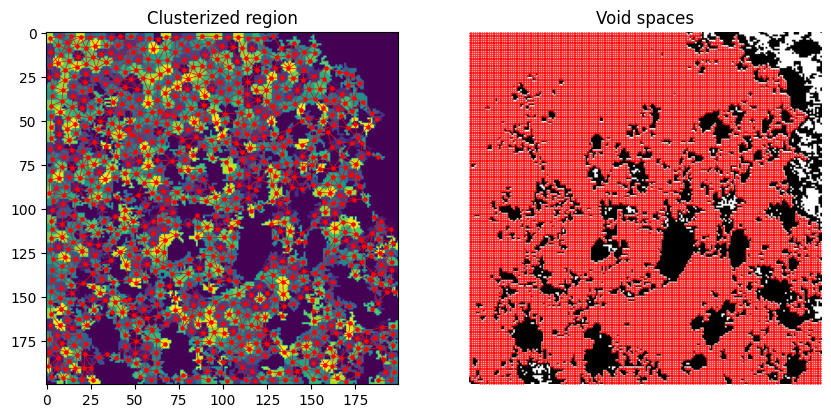

Número de ligações: 2576


In [203]:
import random
import matplotlib.pyplot as plt

# Comprimento da lista resultados_kmeans
length = len(resultados_gmm)

# Gerar um número aleatório entre 0 e length-1
random_index = random.randint(0, length - 1)

# Gerar um número aleatório entre 0 e o comprimento da lista de resultados - 1
##random_number_kmean = random_index
random_number_kmean = 0
numero_de_elementos_na_região = np.count_nonzero(resultados_gmm[random_number_kmean])
print("Random number_kmean:", random_number_kmean, numero_de_elementos_na_região, 'number_of_pores', number_of_pores_gm[random_number])
# Obter a região clusterizada aleatória e seus centros
regiao_aleatoria = resultados_gmm[random_number_kmean]
centros = coordenadas_centros_gm[random_number_kmean]

# Definir uma distância máxima entre centros para considerá-los lado a lado


# Inicializar uma figura
plt.figure(figsize=(10, 10))

# Plotar a região clusterizada
plt.subplot(121)
plt.imshow(regiao_aleatoria)
plt.title('Clusterized region')
# Plotar os centros dos clusters
for centro in centros:
    plt.scatter(centro[1], centro[0], color='red', marker='o', s=5)

# Função para calcular a distância entre dois pontos
def distancia_entre_pontos(p1, p2):
    return ((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)**0.5

# Ligando os centros dos clusters de regiões lado a lado
# Inicialize uma variável para contar o número de ligações
numero_de_ligacoes = 0
for i in range(len(centros)):
    for j in range(i + 1, len(centros)):
        distancia = distancia_entre_pontos(centros[i], centros[j])
        if distancia <= distancia_maxima:
            plt.plot([centros[i][1], centros[j][1]], [centros[i][0], centros[j][0]], 'r-', linewidth=0.5)  # 'r-' para uma linha vermelha
            numero_de_ligacoes += 1

# Exemplo de acesso a uma região segmentada e suas coordenadas
indice_da_regiao = random_number_kmean  # Índice da região desejada
regiao_segmentada_desejada = regioes_segmentadas[indice_da_regiao]
coordenadas_da_regiao_desejada = coordenadas_poros[indice_da_regiao]
plt.subplot(122)
plt.imshow(binary_image, cmap='gray')
plt.plot(coordenadas_da_regiao_desejada[0], coordenadas_da_regiao_desejada[1], 'r.', markersize=1)
plt.title('Void spaces')
plt.axis('off')

# Mostrar o gráfico

plt.show()
# Exibir o número de ligações
print("Número de ligações:", numero_de_ligacoes)

## Gaussian mixture: Plot the ratio of aspect, Number of connections x void  and spaces and Number of pores x void spaces 

In [186]:
len(ratio_of_aspect_cluster_gm)

200

In [187]:
from itertools import chain
# Utilizando itertools.chain para "descompactar" todas as listas internas em uma única lista
all_aspect_ratios_gm = list(chain(*ratio_of_aspect_cluster_gm))

In [188]:
len(all_aspect_ratios_gm)

1184

In [189]:
count_spherical_pores_gm = len(list(filter(lambda x: x == 1, all_aspect_ratios_gm)))

Number of pores that are spherical: 0


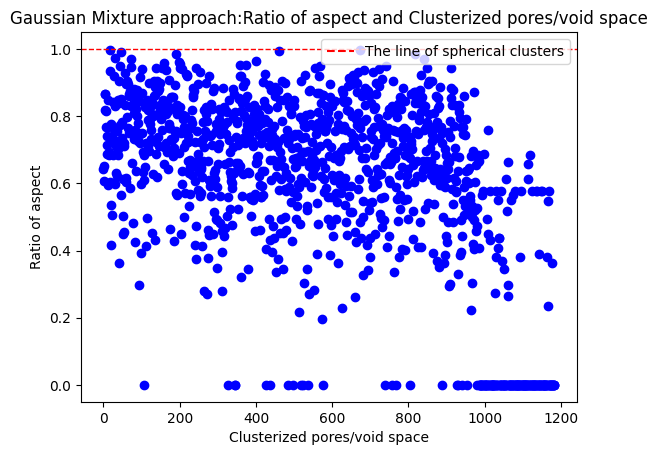

In [190]:
print('Number of pores that are spherical:', count_spherical_pores_gm)
# Plotar os pontos (void space no eixo x e número de ligações no eixo y)
plt.plot(all_aspect_ratios_gm, 'bo')

# Adicionar uma linha horizontal ao longo do valor zero no eixo y
plt.axhline(1, color='red', linestyle='--', linewidth=1)

# Adicionar uma linha separada com a mesma cor e estilo para a legenda
plt.plot([], [], color='red', linestyle='--', label='The line of spherical clusters')

# Adicionar a legenda
plt.legend()

# Adicionar rótulos aos eixos
plt.xlabel('Clusterized pores/void space')
plt.ylabel('Ratio of aspect')
plt.title('Gaussian Mixture approach:Ratio of aspect and Clusterized pores/void space')
plt.show()

In [191]:
import random
import matplotlib.pyplot as plt

# Lista para armazenar o número de ligações para cada região clusterizada
numero_de_ligacoes_por_regiao_gm = []

# Iterar sobre as regiões clusterizadas
for i in range(len(resultados_gmm)):
    # Obter a região clusterizada atual e seus centros
    regiao = resultados_gmm[i]
    centros = coordenadas_centros_gm[i]

    # Definir uma distância máxima entre centros para considerá-los lado a lado
    #distancia_maxima = 5  # Ajuste conforme necessário

    # Inicializar uma variável para contar o número de ligações para esta região
    numero_de_ligacoes_gm = 0

    # Ligando os centros dos clusters de regiões lado a lado
    for i in range(len(centros)):
        for j in range(i + 1, len(centros)):
            distancia = distancia_entre_pontos(centros[i], centros[j])
            if distancia <= distancia_maxima:
                numero_de_ligacoes_gm += 1

    # Adicionar o número de ligações para esta região à lista
    numero_de_ligacoes_por_regiao_gm.append(numero_de_ligacoes_gm)

# Exibir a lista de número de ligações para cada região clusterizada
print(numero_de_ligacoes_por_regiao_gm)



[2576, 0, 16, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


Number of void spaces without pores: 107


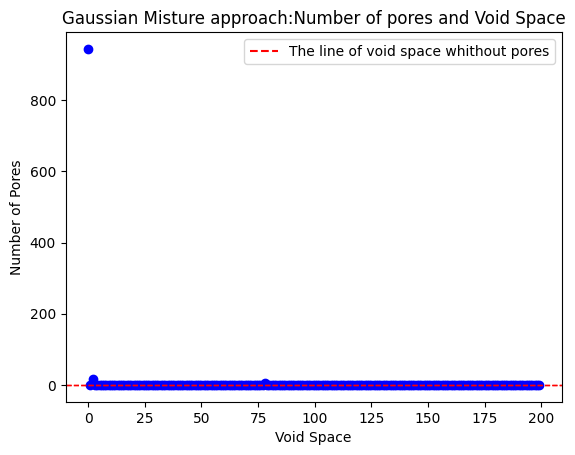

In [192]:
count_zeros_gm = len(list(filter(lambda x: x == 0, number_of_pores_gm)))
print(f"Number of void spaces without pores: {count_zeros_gm}")
# Plotar os pontos
plt.plot(number_of_pores_gm, 'bo')

# Adicionar uma linha horizontal ao longo do valor zero no eixo y
plt.axhline(0, color='red', linestyle='--', linewidth=1)

# Adicionar uma linha horizontal ao longo do valor zero no eixo y
plt.axhline(0, color='red', linestyle='--', linewidth=1)

# Adicionar uma linha separada com a mesma cor e estilo para a legenda
plt.plot([], [], color='red', linestyle='--', label='The line of void space whithout pores')

plt.legend()
# Adicionar rótulos aos eixos
plt.xlabel('Void Space')
plt.ylabel('Number of Pores')
plt.title('Gaussian Misture approach:Number of pores and Void Space')
plt.show()

Number of isolated pores: 197


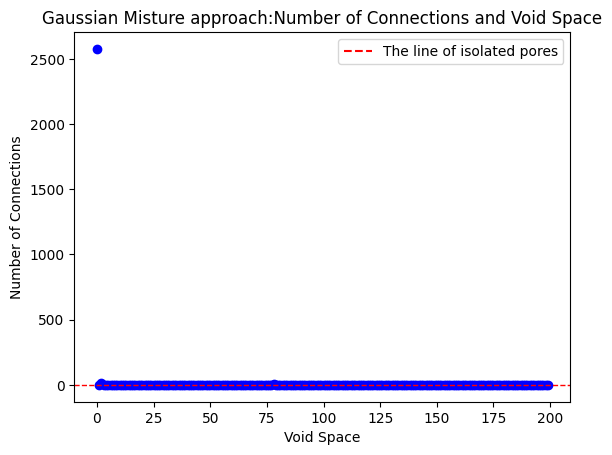

In [193]:
count_zeros_lig_gm = len(list(filter(lambda x: x == 0, numero_de_ligacoes_por_regiao_gm)))

print(f"Number of isolated pores: {count_zeros_lig_gm}")
import matplotlib.pyplot as plt

# Plotar os pontos (void space no eixo x e número de ligações no eixo y)
plt.plot(numero_de_ligacoes_por_regiao_gm, 'bo')

# Adicionar uma linha horizontal ao longo do valor zero no eixo y
plt.axhline(0, color='red', linestyle='--', linewidth=1)

# Adicionar uma linha separada com a mesma cor e estilo para a legenda
plt.plot([], [], color='red', linestyle='--', label='The line of isolated pores')

# Adicionar a legenda
plt.legend()

# Adicionar rótulos aos eixos
plt.xlabel('Void Space')
plt.ylabel('Number of Connections')
plt.title('Gaussian Misture approach:Number of Connections and Void Space')
plt.show()

In [194]:
height, width = im.shape

In [195]:
height, width

(200, 200)

In [196]:
pixel_area = 1
total_area = height * width

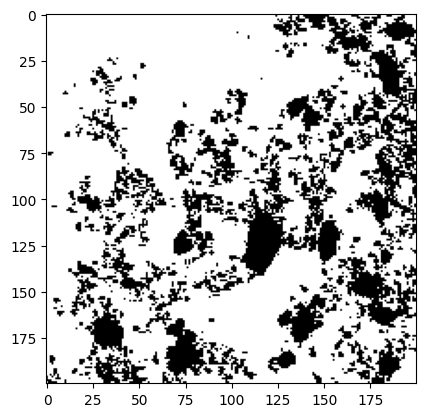

In [197]:
plt.imshow(binary_image, cmap='gray')

In [198]:
binary_image.min(), binary_image.max()

(0, 1)

In [199]:
binary_image = binary_image.astype('uint8')

In [200]:
# When you set the pore to be the value 1 # background 
# You are suppose to use the calculate_pore_properties_gray_version_rock to calculate the properties
import numpy as np

def calculate_pore_properties_gray_version_rock(segmented_image, pixel_area, total_area):
    """
    Calculate pore properties including pore area and porosity for a grayscale segmented image.

    Parameters:
    - segmented_image: 2D segmented image where pores are represented by values between 0 and 1.
    - pixel_area: Area of a single pixel in the image.

    Returns:
    - grain_area: Total area of segmented grain regions.
    - fraction_matrix: matrix calculated as the ratio of grain area to the total area.
    """
    # Check if the input image is within the valid range
    if not (np.all(0 <= segmented_image) and np.all(segmented_image <= 1)):
        raise ValueError("Input image must have values between 0 and 1 for grayscale segmentation.")
    # Calculate pore area
    pore_area = np.sum(segmented_image) * pixel_area
    
    # Calculate total area of the image
    #total_area = np.sum(segmented_image >= 0) * pixel_area
    ##total_area = np.sum(segmented_image >= segmented_image.min()) * pixel_area
    ##total_area = circle_area
    # Calculate porosity
    porosity = pore_area / total_area
    fraction_matrix = 1.0 - porosity
    grain_area = total_area - pore_area
    return grain_area, fraction_matrix, porosity, pore_area

In [201]:
grain_area_sinthetic, fraction_matrix_sinthetic, porosity_sinthetic, pore_area_sinthetic = calculate_pore_properties_gray_version_rock(binary_image, pixel_area, total_area) 

In [202]:
print('The grain area:', grain_area_sinthetic,'in pixels')
print('The fraction matrix:', fraction_matrix_sinthetic,'in percentage')
print('The porosity:', porosity_sinthetic,'in percentage')
print('The pore area:', pore_area_sinthetic,'in pixels')

The grain area: 10330 in pixels
The fraction matrix: 0.25825 in percentage
The porosity: 0.74175 in percentage
The pore area: 29670 in pixels


## Estimating the tortuosity with the equation:
$\tau=\frac{l}{r}$


where l is the distance of the trajetory and r is the the distance between the initial point and final.

Random number_kmean: 0 28245 number_of_pores 944


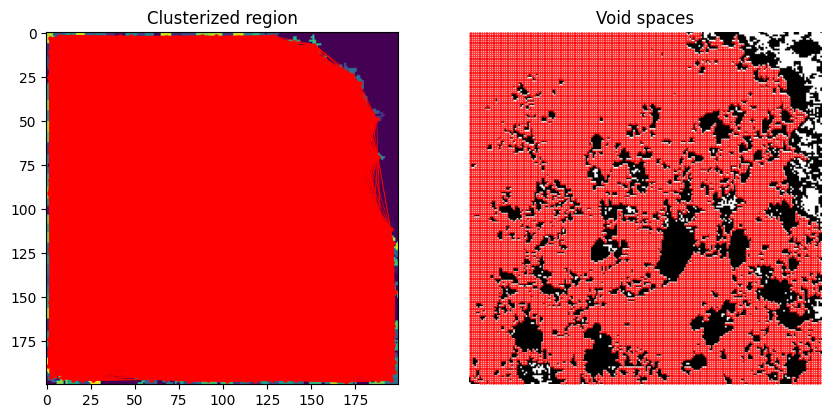

Número de ligações: 72689
Vetores trajetórias: 

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [204]:
import random
import matplotlib.pyplot as plt
import numpy as np

# Supondo que resultados_gmm, coordenadas_centros_gm, distancia_maxima, regioes_segmentadas,
# coordenadas_poros, binary_image, e number_of_pores_gm estejam definidos previamente

# Comprimento da lista resultados_gmm
length = len(resultados_gmm)

# Gerar um número aleatório entre 0 e length-1
random_index = random.randint(0, length - 1)

# Gerar um número aleatório entre 0 e o comprimento da lista de resultados - 1
random_number_kmean = 0
numero_de_elementos_na_região = np.count_nonzero(resultados_gmm[random_number_kmean])
print("Random number_kmean:", random_number_kmean, numero_de_elementos_na_região, 'number_of_pores', number_of_pores_gm[random_number_kmean])

# Obter a região clusterizada aleatória e seus centros
regiao_aleatoria = resultados_gmm[random_number_kmean]
centros = coordenadas_centros_gm[random_number_kmean]

# Definir uma distância máxima entre centros para considerá-los lado a lado
distancia_maxima = 50  # Defina a distância máxima desejada

# Inicializar uma figura
plt.figure(figsize=(10, 10))

# Plotar a região clusterizada
plt.subplot(121)
plt.imshow(regiao_aleatoria)
plt.title('Clusterized region')
# Plotar os centros dos clusters
for centro in centros:
    plt.scatter(centro[1], centro[0], color='red', marker='o', s=5)

# Função para calcular a distância entre dois pontos
def distancia_entre_pontos(p1, p2):
    return ((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)**0.5

# Inicialize uma variável para contar o número de ligações
numero_de_ligacoes = 0

# Lista para armazenar os vetores trajetórias
vetores_trajetorias = []

# Variável para armazenar a maior trajetória
maior_trajetoria = (None, None, 0)  # (ponto inicial, ponto final, comprimento)

for i in range(len(centros)):
    for j in range(i + 1, len(centros)):
        distancia = distancia_entre_pontos(centros[i], centros[j])
        if distancia <= distancia_maxima:
            plt.plot([centros[i][1], centros[j][1]], [centros[i][0], centros[j][0]], 'r-', linewidth=0.5)  # 'r-' para uma linha vermelha
            numero_de_ligacoes += 1
            # Adicionar o vetor trajetória à lista
            vetor_trajetoria = (centros[i], centros[j])
            vetores_trajetorias.append(vetor_trajetoria)
            # Verificar se é a maior trajetória
            if distancia > maior_trajetoria[2]:
                maior_trajetoria = (centros[i], centros[j], distancia)

# Exemplo de acesso a uma região segmentada e suas coordenadas
indice_da_regiao = random_number_kmean  # Índice da região desejada
regiao_segmentada_desejada = regioes_segmentadas[indice_da_regiao]
coordenadas_da_regiao_desejada = coordenadas_poros[indice_da_regiao]
plt.subplot(122)
plt.imshow(binary_image, cmap='gray')
plt.plot(coordenadas_da_regiao_desejada[0], coordenadas_da_regiao_desejada[1], 'r.', markersize=1)
plt.title('Void spaces')
plt.axis('off')

# Mostrar o gráfico
plt.show()
